<p style="padding: 10px; border: 1px solid black;">
<img src="../mlu_utils/images/MLU-NEW-logo.png" alt="drawing" width="400"/> <br/>
<div style="background-color: #1A5276; padding: 20px; border-radius: 10px; text-align: center; margin-bottom: 30px;">
    <h1 style="color: white; margin: 0;">MLU: Building Applications with Foundation Models</h1>
    <h2 style="color: white; margin-top: 15px;">Lab 4: Agents</h2>
</div>

In this notebook, we leverage an LLM's reasoning capabilities to plan and execute actions in order to solve a task. We will use LangChain tools to allow LLMs to interface with external sources. Tools are functions or APIs which help provide the LLM with relevant context. We will be examining some popular built-in tool integrations in this notebook. Agents harness the reasoning capabilities of LLMs to plan actions to solve the task. LangChain agents have the capability to not only plan, but also execute the actions decided upon. An agent can be given access to tools, which the agent may select to solve the task. In this notebook we will develop custom agents with access to certain tools, and observe how the agent selects the appropriate tool, retrieves the results using the selected tool, and produces the final response.

<!-- Table of Contents -->
<div id="section0" style="background-color: #EBF5FB; padding: 15px; border-radius: 5px; margin-bottom: 30px;">
    <h2 style="color: #2874A6; border-bottom: 1px solid #2874A6; padding-bottom: 5px;">Table of contents</h2>
    <p><a href="#section1" style="color: #2E86C1; font-weight: bold; text-decoration: none;">1. Setup and configuration</a></p>
    <ul style="margin-top: 0; padding-left: 30px;">
        <li><a href="#section1-1" style="color: #3498DB; text-decoration: none;">1.1 Import dependencies</a></li>
        <li><a href="#section1-2" style="color: #3498DB; text-decoration: none;">1.2 Validate LLM model access</a></li>
    </ul>
    <p><a href="#section2" style="color: #2E86C1; font-weight: bold; text-decoration: none;">2. Define the Amazon Bedrock model for inference</a></p>
    <p><a href="#section3" style="color: #2E86C1; font-weight: bold; text-decoration: none;">3. Tools and toolkits</a></p>
    <ul style="margin-top: 0; padding-left: 30px;">
        <li><a href="#section3-1" style="color: #3498DB; text-decoration: none;">3.1 Wikipedia tool</a></li>
        <li><a href="#section3-2" style="color: #3498DB; text-decoration: none;">3.2 PubMed tool</a></li>
        <li><a href="#section3-4" style="color: #3498DB; text-decoration: none;">3.4 File system tool</a></li>
        <li><a href="#section3-5" style="color: #3498DB; text-decoration: none;">3.5 Custom tool</a></li>
    </ul>
    <p><a href="#section4" style="color: #2E86C1; font-weight: bold; text-decoration: none;">4. Agents</a></p>
    <ul style="margin-top: 0; padding-left: 30px;">
        <li><a href="#section4-1" style="color: #3498DB; text-decoration: none;">4.1 Python agent</a></li>
        <li><a href="#section4-2" style="color: #3498DB; text-decoration: none;">4.2 Q&A with structured data</a></li>
        <li><a href="#section4-3" style="color: #3498DB; text-decoration: none;">4.3 Agent with automatic tool selection</a></li>
    </ul>
    <p><a href="#section5" style="color: #2E86C1; font-weight: bold; text-decoration: none;">5. Quizzes</a></p>
</div>



You will be presented with two kinds of exercises throughout the notebook: activities and challenges. <br/>

<!-- Compact Lab Introduction with Activity/Challenge Explanation -->
<div style="background-color: #F8F9F9; padding: 15px; border-radius: 5px; margin: 20px 0;">
    <h4 style="color: #2E4053; margin-top: 0;">About this Lab</h4>
    <p>Throughout this lab, you will encounter two types of interactive elements:</p>
    <table style="width: 100%; border-collapse: collapse; margin: 15px 0;">
        <tr>
            <td style="text-align: center; padding: 10px; width: 50%;">
                <img src="../mlu_utils/images/activity.png" alt="Activity" width="125"/>
            </td>
            <td style="text-align: center; padding: 10px; width: 50%;">
                <img src="../mlu_utils/images/challenge.png" alt="Challenge" width="125"/>
            </td>
        </tr>
        <tr>
            <td style="text-align: center; padding: 10px; background-color: #EBF5FB;">
                <p>No coding is needed for an activity. You try to understand a concept, answer questions, or run a code cell.</p>
            </td>
            <td style="text-align: center; padding: 10px; background-color: #FEF9E7;">
                <p>Challenges are where you test your understanding by implementing something new or taking a short quiz.</p>
            </td>
        </tr>
    </table>
    <p>Please work through this notebook from top to bottom to avoid errors due to missing code or context.</p>
</div>


<!-- Section Header -->
<div id="section1" style="border-left: 5px solid #3498DB; padding-left: 15px; margin: 40px 0 20px 0;">
    <h2 style="color: #2874A6;">1. Setup and configuration</h2>
</div>
(<a href="#section0">Go to top</a>)

First, let's install and import the necessary libraries, including the [LangChain](https://python.langchain.com/docs/how_to/installation/) library.

In [ ]:
%%capture
!pip3 install -r ../requirements.txt --quiet

In [ ]:
import sys
sys.path.append('..')

import boto3
import json
from datetime import date, time

import warnings
from IPython.display import Markdown

warnings.filterwarnings("ignore")

---
<!-- Subsection Header -->
<div id="section1-2" style="border-left: 3px solid #85C1E9; padding-left: 12px; margin: 25px 0 15px 15px;">
    <h3 style="color: #2E86C1;">1.2. Validate LLM model access</h3>
</div>
(<a href="#0">Go to top</a>)

As a first step we need to verify that the LLM models required in this lab are accessible.  Lets do that now by using the helper function `validate_models_access` and provide the list of LLM models that we require for this lab.  If the call to `validate_models_access` returns any model ids in the output list then you will need to go to the `Amazon Bedrock` console and enable access to the required models.

In [ ]:
from mlu_utils.helpers import validate_models_access

if not validate_models_access(["amazon.nova-lite-v1:0", "mistral.mixtral-8x7b-instruct-v0:1", "amazon.nova-lite-v1:0"]):
    print("The models are accessible. You can go ahead running this notebook.")

<!-- Section Header -->
<div id="section2" style="border-left: 5px solid #3498DB; padding-left: 15px; margin: 40px 0 20px 0;">
    <h2 style="color: #2874A6;">2. Define the Amazon Bedrock model for inference</h2>
    (<a href="#section0">Go to top</a>)
</div>
Let's select the Amazon Bedrock model the same way we did in the previous labs.

<!-- Tip Box -->
<div style="background-color: #E8F8F5; border-left: 5px solid #1ABC9C; padding: 15px; border-radius: 5px; margin: 20px 0;">
    <p style="color: #16A085; margin: 0;"><strong>Tip:</strong> Please opt for frugal practices when using Amazon Bedrock such as using smaller LLMs for simpler tasks and only reserving the use of the larger LLMs for more complex use cases.</p>
</div>

In [ ]:
from langchain_aws import ChatBedrockConverse
from langchain_core.output_parsers import StrOutputParser


bedrock_llm = ChatBedrockConverse(
    model="amazon.nova-lite-v1:0",
    temperature=0,
    max_tokens=None,
)

<!-- Section Header -->
<div id="section3" style="border-left: 5px solid #3498DB; padding-left: 15px; margin: 40px 0 20px 0;">
    <h2 style="color: #2874A6;">3. Tools and toolkits</h2>
(<a href="#section0">Go to top</a>)
</div>

In this section, we will explore various LangChain tools that allow LLMs to interface with external sources. Tools are functions or APIs which help provide the LLM with relevant context.

Tools are functions that agents can use to interact with the world. These tools can be generic utilities (e.g. search), other chains, or even other agents. With tools, **LLMs can search the web, do math, run code**, and more. While the LangChain library provides a [substantial selection of pre-built tools](https://python.langchain.com/docs/integrations/tools/), in many real-world projects, we'll often find that existing tool might not work out-of-the-boxi as expected. Eventually we might need to modify existing tools or build entirely new ones.

In [ ]:
# Load libraries for the upcoming cells
from langchain.agents import Tool
from langchain.tools import tool

<!-- Sub-subsection Header -->
<div id="section3-1" style="border-left: 2px solid #AED6F1; padding-left: 10px; margin: 20px 0 15px 30px;">
    <h3 style="color: #3498DB;">3.1 Wikipedia tool</h3>
</div>

Wikipedia is a multilingual free online encyclopedia written and maintained by a community of volunteers, through open collaboration. It is the largest and most-read reference work in history. \
To use the Wikipedia tool, you need to first install the <code>wikipedia</code> package.

In [ ]:
from langchain.utilities import WikipediaAPIWrapper

# Define the API wrapper for Wikipedia
wikipedia = WikipediaAPIWrapper()

# Define the Wikipedia tool with a description and the function to retrieve results from Wikipedia
wikipedia_tool = Tool(
    name="WikipediaTool",
    func=wikipedia.run,
    description="Useful to answer general questions about people, places, companies, facts, historical events, or other subjects.",
)

# Test the defined Wikipedia tool
Markdown(wikipedia_tool.invoke("What is the Archimedes Principle?"))

<!-- Sub-subsection Header -->
<div id="section3-2" style="border-left: 2px solid #AED6F1; padding-left: 10px; margin: 20px 0 15px 30px;">
    <h3 style="color: #3498DB;">3.2 PubMed tool</h3>
</div>

 PubMed is a free search engine for medical papers and articles.
 Let's create a PubMed tool capable of retrieving search results from PubMed.

In [ ]:
from langchain.tools import PubmedQueryRun

# Define the API wrapper for PubMed search
pubmed_search = PubmedQueryRun()

# Define the PubMed tool using a description and the function to retrieve results from PubMed
pubmed_tool = Tool(
    name="PubmedQueryRun",
    func=pubmed_search.run,
    description="Useful for when you need medical information",
)

# Test PubMed tool
Markdown(pubmed_tool.invoke("Covid diagnosis"))

<!-- Sub-subsection Header -->
<div id="section3-3" style="border-left: 2px solid #AED6F1; padding-left: 10px; margin: 20px 0 15px 30px;">
    <h3 style="color: #3498DB;">3.4 File system tool</h3>
</div>

The file system tools allow an LLM to interact with the local file system. You can also choose to load all the file system tools by simply loading the <code>FileManagementToolkit</code>.

<!-- Important Note -->
<div style="background-color: #FDEDEC; border-left: 5px solid #E74C3C; padding: 15px; border-radius: 5px; margin: 20px 0;">
    <p style="color: #C0392B; margin: 0;"><strong>Important:</strong> Take caution when using this tool in production environments. The results may be inconsistent or incorrect.</p>
</div>

In [ ]:
from langchain.agents.agent_toolkits import FileManagementToolkit
from langchain.tools.file_management import (
    ReadFileTool,
    CopyFileTool,
    DeleteFileTool,
    MoveFileTool,
    WriteFileTool,
    ListDirectoryTool,
)

# File management toolkit
file_management_toolkit = FileManagementToolkit(
    selected_tools=["read_file", "list_directory"],
)

# Define the module for list directory tool
list_dir = ListDirectoryTool()

# Define the list directory tool as a structured tool
@tool
def list_dir_tool(directory_path: str) -> str:
    """List the contents of a directory. Input is the path to the directory."""
    return list_dir.run(directory_path.strip().strip('"').strip("'"))

# Test list directory tool
print(list_dir_tool.invoke("./"))

<!-- Sub-subsection Header -->
<div id="section3-4" style="border-left: 2px solid #AED6F1; padding-left: 10px; margin: 20px 0 15px 30px;">
    <h3 style="color: #3498DB;">3.5 Custom tool</h3>
</div>

You can define custom tools using the <code>tool</code> decorator.\
DuckDuckGo is an internet privacy company most popularly known for their private search engine. The company emphasizes privacy and anonymity as one of the key principles behind all their products.\
Let's create a DuckDuckGo tool that is capable of retrieving results from a web search.

In [ ]:
#from duckduckgo_search import DDGS
from ddgs import DDGS
from langchain.document_loaders import UnstructuredURLLoader

@tool
def web_search(text: str) -> str:
    """Retrieve information about current events from a web search using an input query."""

    results = "".join([result['body'] for result in list(DDGS().text(text, backend='lite', region='us-en', safesearch='on', max_results=5))])

    return results

In [ ]:
# Define the web search tool
web_search_tool = Tool(
    name="WebSearchTool", func=web_search, description="Useful to retrieve current events from a web search."
)

Markdown(web_search_tool.run("Name of the 6th president of US?"))

<!-- Code Example Preview -->
<div style="background-color: #EAECEE; padding: 15px; border-radius: 5px; margin: 20px 0;">
    <h4 style="color: #566573; margin-top: 0;">Code Example: Custom Date Tool</h4>
    <p>Let's define another custom tool that returns the current date regardless of the input.</p>
</div>

In [ ]:
@tool
def curr_date(text: str) -> str:
    """Returns todays date, use this for any \
    questions related to knowing todays date. \
    The input should always be an empty string, \
    and this function will always return todays \
    date - any date math should occur \
    outside this function."""
    return str(date.today())

In [ ]:
# Define the date tool
date_tool = Tool(
    name="DateTool", func=curr_date, description="Useful to retrieve the current date"
)

# Test date tool
print(date_tool.run("Test"))

<!-- Section Header -->
<div id="section4" style="border-left: 5px solid #3498DB; padding-left: 15px; margin: 40px 0 20px 0;">
    <h2 style="color: #2874A6;">4. Agents</h2>
(<a href="#section0">Go to top</a>)
</div>

An LLM can be perceived as more than a source of knowledge that can be queried. LLMs have also demonstrated strong reasoning capabilities. More and more, LLMs are being popularly used as reasoning engines to plan a series of actions to take, as well as to define their execution order.
A LangChain agent uses an LLM to plan the actions and allow their execution. Agents can be given access to tools to solve a task. An agent creates a plan to use the appropriate tool based on the prompt, runs the tool to retrieve the results, and produces the final response.

An Agent is a wrapper around a model, which takes in user input and returns a response corresponding to an "action" to take and a corresponding "action input". With agents, an **LLM is used as a reasoning engine** to determine which actions to take and in which order.

LangChain provides a utility to initialize an agent. To do so, we need to pass the following parameters:

- **`tools`**: a list of tools that the model has access to
- **`llm`**: the language model that will perform the reasoning and act process
- **`agent`**: the type of agent that we want to initialize

<!-- Tip Box -->
<div style="background-color: #E8F8F5; border-left: 5px solid #1ABC9C; padding: 15px; border-radius: 5px; margin: 20px 0;">
    <p style="color: #16A085; margin: 0;"><strong>Tip:</strong>  LangChain agents are very specialized for models with extensive reasoning capabilities and may not work perfectly with other LLMs.</p>
</div>

<!-- Sub-subsection Header -->
<div id="section4-1" style="border-left: 2px solid #AED6F1; padding-left: 10px; margin: 20px 0 15px 30px;">
    <h3 style="color: #3498DB;">4.1 Python agent</h3>
</div>

Let's use the <code>PythonREPLTool</code> to define a Python agent capable of writing and implementing Python code. This is simply a demonstration. Expect errors while implementing the next cell. The intention of this is to demonstrate how an agent reasons to solve a task.

<!-- Important Note -->
<div style="background-color: #FDEDEC; border-left: 5px solid #E74C3C; padding: 15px; border-radius: 5px; margin: 20px 0;">
    <p style="color: #C0392B; margin: 0;"><strong>Warning!</strong> This demo does not use or teach security best practices. You should not allow Generative AI to run arbitrary code on production systems.</p>
</div>

In [ ]:
from langchain_experimental.tools import PythonREPLTool
from langchain.agents import AgentType
from langchain.agents import initialize_agent

# Define the tool
python_repl = PythonREPLTool()

# Define the agent with the PythonReplTool using tool-calling
python_agent = initialize_agent(
    [PythonREPLTool()],
    bedrock_llm,
    agent=AgentType.STRUCTURED_CHAT_ZERO_SHOT_REACT_DESCRIPTION,
    verbose=True,
    handle_parsing_errors=True,
)

### Customizing the agent's prompt template

LangChain's Zero-shot React Description agent orchestrates the sequence of thoughts-actions-observations via a default template that is stored in `agent.agent.llm_chain.prompt.template` as you can see below. 

For more control on the ReAct results, it is possible to **customize the LLM agent's prompt template**, as demonstrated in this [Custom LLM agent walkthrough](https://python.langchain.com/docs/modules/agents/how_to/custom_llm_agent). This way, one can force the agent to output the final answer in a special format or style. Similarly, one can make rules to the LLM explicit in the prompt template, for instance adding an instruction for the LLM to always use a particular tool as the first tool or enforcing a specific order constraint when calling the available tools. 

In [ ]:
# Default prompt template of the agent
for msg in python_agent.agent.llm_chain.prompt.messages:
    print(type(msg).__name__, ':', msg.prompt.template if hasattr(msg, 'prompt') else msg)
    print()

In [ ]:
# Test the python Agent
python_agent.invoke(
    {
        "input": "Calculate the mean and standard deviation of the following numbers: 13, 8, 53, 77, 91, 27"
    }
)

<!-- Sub-subsection Header -->
<div id="section4-2" style="border-left: 2px solid #AED6F1; padding-left: 10px; margin: 20px 0 15px 30px;">
    <h3 style="color: #3498DB;">4.2 Q&A with structured data</h3>
</div>

Let's create a pandas dataframe agent, capable of writing Python code to query and extract data from the dataframe. This is simply a demonstration. Expect errors while implementing the next cell. The intention of this is to demonstrate how an agent reasons to solve a task.

For this example, we will be using the [Electric Vehicle Population Data](https://data.wa.gov/Transportation/Electric-Vehicle-Population-Data/f6w7-q2d2/about_data) dataset that shows the Battery Electric Vehicles (BEVs) and Plug-in Hybrid Electric Vehicles (PHEVs) that are currently registered through Washington State Department of Licensing (DOL).

In [ ]:
from langchain_experimental.agents import create_pandas_dataframe_agent, create_csv_agent
import pandas as pd

df = pd.read_csv('data/Electric_Vehicle_Population_Data.csv')
df.head()

In [ ]:
agent = create_pandas_dataframe_agent(
    bedrock_llm,
    df,
    verbose=True,
    agent_type="tool-calling",
    handle_parsing_errors=True,
    allow_dangerous_code=True,
)

# The CSV agent is quite fickle. We will append helpful instructions to the prompt to make the agent more robust.
prompt = """{} The results from the tool execution might be the extracted rows. Analyze the output of the tool first before proceeding."""

In [ ]:
response = agent.invoke({"input": prompt.format("What are the top 5 models sold? Give me the number of units sold as well.")})

In [ ]:
# Print the final response
output = response['output']
# Handle Nova models returning a list of content blocks instead of a plain string
if isinstance(output, list):
    output = '\n'.join(block.get('text', '') for block in output if isinstance(block, dict))
Markdown(output)

<!-- Sub-subsection Header -->
<div id="section4-3" style="border-left: 2px solid #AED6F1; padding-left: 10px; margin: 20px 0 15px 30px;">
    <h3 style="color: #3498DB;">4.3 Agent with automatic tool selection</h3>
</div>

The last example shows how an agent uses the <code>PythonREPL</code> tool to write Python code and execute it to obtain the desired results. In the next demonstration, let's use an agent which has access to more than one tool and is required to perform the following tasks:

- Reason and select the relevant tool based on the prompt
- Create the query for the selected tool to get the desired results
- Analyze the results and generate the correct answer in response to the prompt

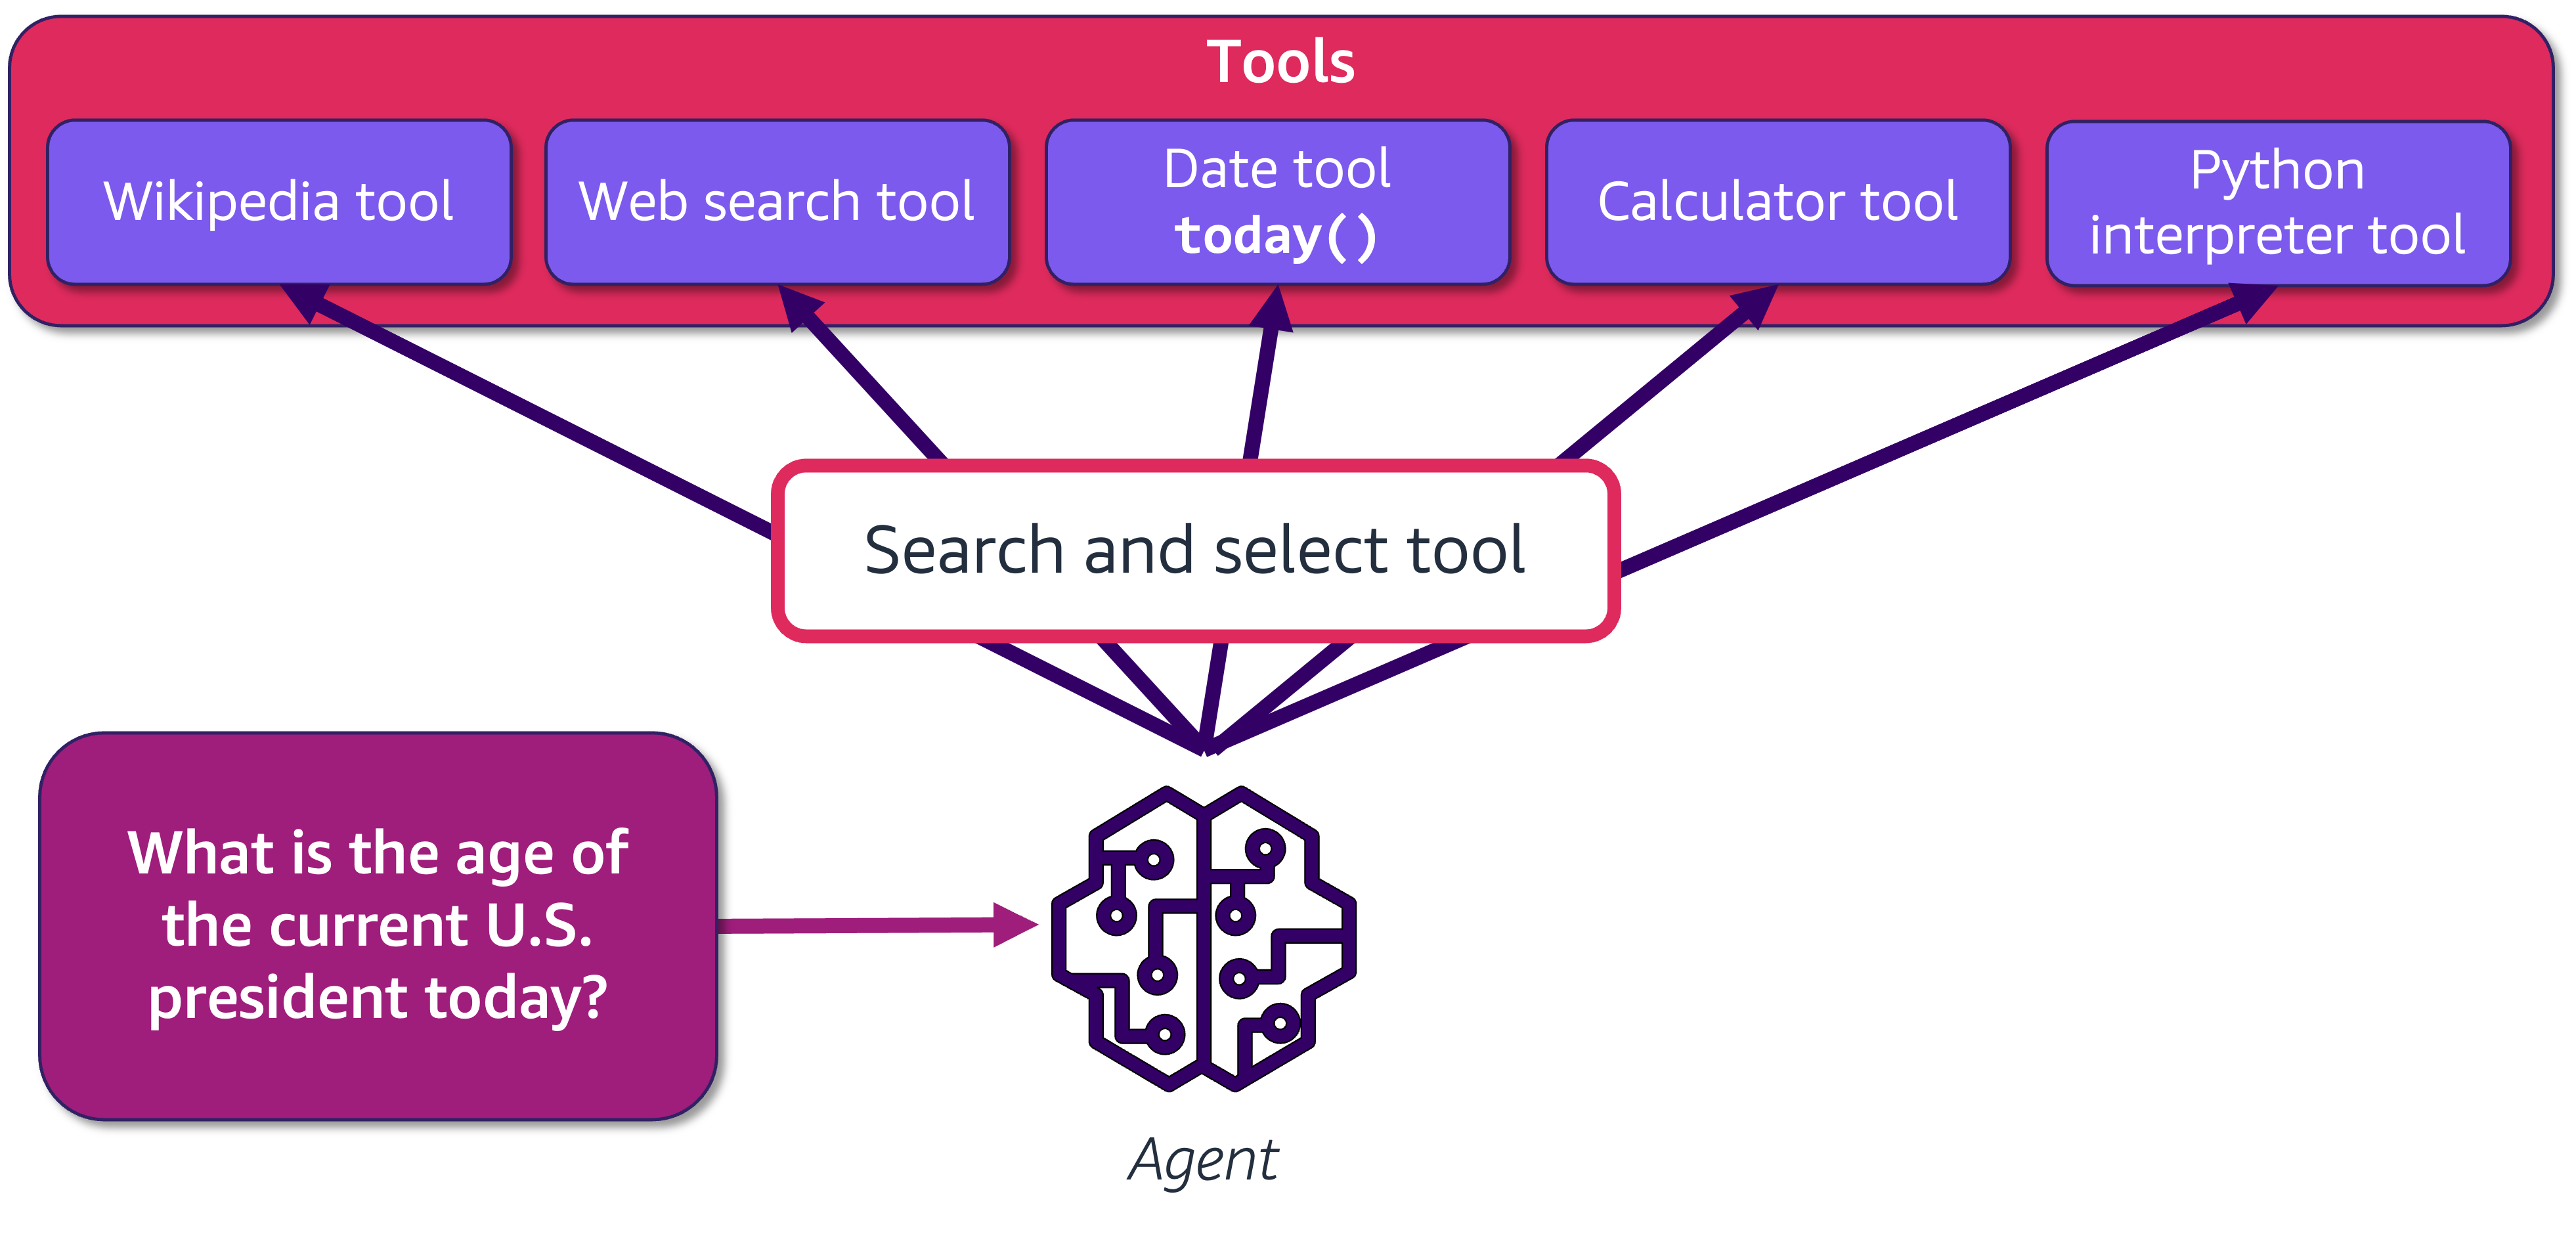

In [ ]:
from langchain.agents import load_tools
from langchain.agents import initialize_agent

# Define a list of available tools for the agent
tools = [
    wikipedia_tool,
    web_search_tool,
    pubmed_tool,
    date_tool,
    python_repl,
    list_dir_tool,
]

agent = initialize_agent(
    agent=AgentType.STRUCTURED_CHAT_ZERO_SHOT_REACT_DESCRIPTION,
    tools=tools,
    llm=bedrock_llm,
    verbose=True,
    handle_parsing_errors=True,
)

<!-- Activity Box -->
<div style="background-color: #EBF5FB; border-left: 5px solid #3498DB; padding: 15px; border-radius: 5px; margin: 20px 0; display: flex; align-items: flex-start;">
    <div style="flex: 0 0 60px; margin-right: 15px;">
        <img src="../mlu_utils/images/activity.png" alt="Activity" width="200" style="max-width: 100%; height: auto;">
    </div>
    <div style="flex: 1;">
        <h4 style="color: #2874A6; margin-top: 0;">Activity: Try different prompts</h4>
        <p>Try different prompts and observe the responses generated by the agent.</p>
        <p><strong>Note:</strong> Results may not be factually accurate and may be based on false assumptions.</p>
    </div>
</div>

<!-- Sub-sub-subsection Header -->
<div id="section5-3-1" style="border-left: 2px dashed #D6EAF8; padding-left: 8px; margin: 15px 0 10px 45px;">
    <h4 style="color: #5DADE2;">Automatically select and use the DuckDuckGo tool</h4>
</div>

Let's examine whether the agent is able to reason and select the <code>DuckDuckGo</code> tool and the <code>DateTool</code> tool to respond about the weather conditions in New York.

In [ ]:
agent.invoke({"input": "Should I carry an umbrella in New York City tomorrow?"})

<!-- Sub-sub-subsection Header -->
<div id="section5-3-2" style="border-left: 2px dashed #D6EAF8; padding-left: 8px; margin: 15px 0 10px 45px;">
    <h4 style="color: #5DADE2;">Automatically select and use the ListDirTool tool</h4>
</div>

Let's examine whether the agent is able to reason and select the <code>ListDirTool</code> tool to answer questions about the current directory.

In [ ]:
# Invoke the executor chain
agent.invoke({"input": "How many ipynb files do I have?"})

<!-- Sub-sub-subsection Header -->
<div id="section5-3-3" style="border-left: 2px dashed #D6EAF8; padding-left: 8px; margin: 15px 0 10px 45px;">
    <h4 style="color: #5DADE2;">Automatically select and use the Wikipedia tool</h4>
</div>
Let's examine whether the agent is able to reason and select the <code>Wikipedia</code> tool to answer questions about Alexa+.

In [ ]:
agent.invoke({"input": "What is Alexa+ that was launched recently? Tell me more about the company that developed it."})

<!-- Section Header -->
<div id="section5" style="border-left: 5px solid #3498DB; padding-left: 15px; margin: 40px 0 20px 0;">
    <h2 style="color: #2874A6;">5. Quizzes</h2>
</div>

Well done on completing the lab! Now, it's time for a brief knowledge assessment.

<!-- Challenge Box -->
<div style="background-color: #FEF9E7; border-left: 5px solid #F1C40F; padding: 15px; border-radius: 5px; margin: 20px 0; display: flex; align-items: flex-start;">
    <div style="flex: 0 0 60px; margin-right: 15px;">
        <img src="../mlu_utils/images/challenge.png" alt="Challenge" width="200" style="max-width: 100%; height: auto;">
    </div>
    <div style="flex: 1;">
        <h4 style="color: #B7950B; margin-top: 0;">Challenge: Knowledge assessment</h4>
        <p>Answer the following questions to test your understanding of agents.</p>
    </div>
</div>

In [ ]:
from mlu_utils.quiz_questions import lab4_question1, lab4_question2

lab4_question1.display()
lab4_question2.display()

<div style="background-color: #EBF5FB; padding: 15px; border-radius: 5px; margin: 30px 0;">
    <h3 style="color: #2874A6; border-bottom: 1px solid #85C1E9; padding-bottom: 5px;">Conclusion</h3>
    <p>In this lab, you have:</p>
    <ul>
        <li>Explored various LangChain tools that allow LLMs to interface with external sources</li>
        <li>Created and used tools like Wikipedia, PubMed, Math, and File System tools</li>
        <li>Developed custom tools using the tool decorator</li>
        <li>Implemented agents that can reason, select appropriate tools, and execute actions</li>
        <li>Observed how agents can work with structured data and automatically select tools based on the task</li>
    </ul>
    <h4 style="color: #2874A6; margin-top: 15px;">Additional Resources</h4>
    <ul>
        <li><a href="https://python.langchain.com/docs/how_to/#tools">LangChain Tools Documentation</a></li>
        <li><a href="https://python.langchain.com/docs/how_to/#agents">LangChain Agents Documentation</a></li>
    </ul>
</div>

<p style="padding: 10px; border: 1px solid black;">
<img src="../mlu_utils/images/MLU-NEW-logo.png" alt="drawing" width="400"/> <br/>